In [29]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ---- EDIT PATHS ----
DATA_DIR = Path(r"C:\Users\USER\Documents\GitHub\datasets\simbarca\all_agg")
META_DIR = DATA_DIR / "metadata"

PKL_PATH   = DATA_DIR / "agg_timeseries_000.pkl"
LINKS_CSV  = META_DIR / "link_bboxes_clustered.csv"
GRAPH_PATH = Path(r"C:\Users\USER\Documents\GitHub\Traffic-Congestion-Estimation-on-Graphs-via-GP\outputs\centroid_turn.gpickle")

In [30]:
with open(PKL_PATH, "rb") as f:
    data = pickle.load(f)

print("Type:", type(data))
print("Keys:", list(data.keys()))

for k in data.keys():
    v = data[k]
    if hasattr(v, "shape"):
        print(f"{k:12s}  type={type(v).__name__:<12s} shape={v.shape}")
    else:
        print(f"{k:12s}  type={type(v).__name__}")

Type: <class 'collections.defaultdict'>
Keys: ['drone_vdist', 'drone_vtime', 'ld_speed', 'pred_vdist', 'pred_vtime']
drone_vdist   type=DataFrame    shape=(1917, 1570)
drone_vtime   type=DataFrame    shape=(1917, 1570)
ld_speed      type=DataFrame    shape=(54, 1570)
pred_vdist    type=DataFrame    shape=(54, 1570)
pred_vtime    type=DataFrame    shape=(54, 1570)


In [31]:
def to_time_link_df(x):
    """
    Convert common pickle payloads to a DataFrame shaped (time, link_id).
    """
    if isinstance(x, pd.DataFrame):
        df = x.copy()
    elif isinstance(x, pd.Series) and isinstance(x.index, pd.MultiIndex):
        # (time, link_id) -> wide
        df = x.unstack(x.index.names[1])
    else:
        raise TypeError(f"Unsupported type for measurement: {type(x)}")

    # Try to convert link IDs to int
    try:
        df.columns = [int(c) for c in df.columns]
    except Exception:
        pass

    return df

drone_vdist = to_time_link_df(data["drone_vdist"])
drone_vtime = to_time_link_df(data["drone_vtime"])
pred_vdist  = to_time_link_df(data["pred_vdist"])
pred_vtime  = to_time_link_df(data["pred_vtime"])
ld_speed    = to_time_link_df(data["ld_speed"])

drone_vdist.shape, drone_vtime.shape, ld_speed.shape

((1917, 1570), (1917, 1570), (54, 1570))

In [32]:
with open(GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

node_ids = set(map(int, G.nodes()))
print("Graph nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

def filter_to_graph(df):
    # keep only columns that are link IDs in the graph
    if all(isinstance(c, int) for c in df.columns):
        keep = [c for c in df.columns if c in node_ids]
        return df.loc[:, keep]
    return df

drone_vdist = filter_to_graph(drone_vdist)
drone_vtime = filter_to_graph(drone_vtime)
pred_vdist  = filter_to_graph(pred_vdist)
pred_vtime  = filter_to_graph(pred_vtime)
ld_speed    = filter_to_graph(ld_speed)

print("After filtering:")
print("drone_vdist:", drone_vdist.shape, "drone_vtime:", drone_vtime.shape)
print("pred_vdist :", pred_vdist.shape,  "pred_vtime :", pred_vtime.shape)
print("ld_speed   :", ld_speed.shape)

Graph nodes: 1780 edges: 2803
After filtering:
drone_vdist: (1917, 1570) drone_vtime: (1917, 1570)
pred_vdist : (54, 1570) pred_vtime : (54, 1570)
ld_speed   : (54, 1570)


In [33]:
def coverage(df, name):
    total = df.size
    nonmiss = int(df.count().sum())
    pct = 100 * nonmiss / total if total else 0
    print(f"{name:12s} shape={df.shape} non-missing={nonmiss:,}/{total:,} ({pct:.1f}%)")

coverage(drone_vdist, "drone_vdist")
coverage(drone_vtime, "drone_vtime")
coverage(pred_vdist,  "pred_vdist")
coverage(pred_vtime,  "pred_vtime")
coverage(ld_speed,    "ld_speed")

drone_vdist  shape=(1917, 1570) non-missing=1,395,549/3,009,690 (46.4%)
drone_vtime  shape=(1917, 1570) non-missing=1,395,549/3,009,690 (46.4%)
pred_vdist   shape=(54, 1570) non-missing=62,812/84,780 (74.1%)
pred_vtime   shape=(54, 1570) non-missing=62,812/84,780 (74.1%)
ld_speed     shape=(54, 1570) non-missing=62,386/84,780 (73.6%)


In [34]:
def network_metrics_from_vdist_vtime(vdist, vtime, label=""):
    # Totals per time step
    D_t = pd.to_numeric(vdist.sum(axis=1), errors="coerce")  # vehicle-distance (likely meters)
    T_t = pd.to_numeric(vtime.sum(axis=1), errors="coerce")  # vehicle-time (likely seconds)

    # Network average speed (m/s if meters/seconds)
    v_ms_t = D_t / T_t.replace(0, np.nan)

    # Convert to reporting units
    VKT_t = D_t / 1000.0          # meters -> km
    VHT_t = T_t / 3600.0          # seconds -> hours
    v_kmh_t = v_ms_t * 3.6

    # Totals for the whole day/run
    VKT_total = float(VKT_t.sum(skipna=True))
    VHT_total = float(VHT_t.sum(skipna=True))
    v_avg_kmh = float(VKT_total / VHT_total) if VHT_total > 0 else np.nan

    summary = {
        "label": label,
        "VKT_total_vehicle_km": VKT_total,
        "VHT_total_vehicle_h": VHT_total,
        "avg_speed_network_kmh": v_avg_kmh,
        "timesteps": int(len(vdist)),
        "links_used": int(vdist.shape[1]),
    }
    return summary, VKT_t, VHT_t, v_kmh_t

drone_summary, drone_VKT_t, drone_VHT_t, drone_speed_kmh_t = network_metrics_from_vdist_vtime(
    drone_vdist, drone_vtime, label="drone"
)
pred_summary, pred_VKT_t, pred_VHT_t, pred_speed_kmh_t = network_metrics_from_vdist_vtime(
    pred_vdist, pred_vtime, label="pred"
)

pd.DataFrame([drone_summary, pred_summary])

,label,VKT_total_vehicle_km,VHT_total_vehicle_h,avg_speed_network_kmh,timesteps,links_used
0,drone,147101.566454,8141.270631,18.068625,1917,1570
1,pred,147101.566454,8141.270631,18.068625,54,1570


In [35]:
ld_speed_vals = pd.to_numeric(ld_speed.stack(), errors="coerce").dropna()
ld_mean = float(ld_speed_vals.mean())
ld_p50  = float(ld_speed_vals.median())
ld_p95  = float(np.percentile(ld_speed_vals, 95)) if len(ld_speed_vals) else np.nan

print("LD speed stats (raw units):")
print(" mean:", ld_mean)
print(" median:", ld_p50)
print(" p95:", ld_p95)

# convert to km/h for comparison
print("LD mean in km/h (if m/s):", ld_mean * 3.6)

LD speed stats (raw units):
 mean: 10.3047566682872
 median: 10.56011858000284
 p95: 11.680409883121246
LD mean in km/h (if m/s): 37.09712400583392


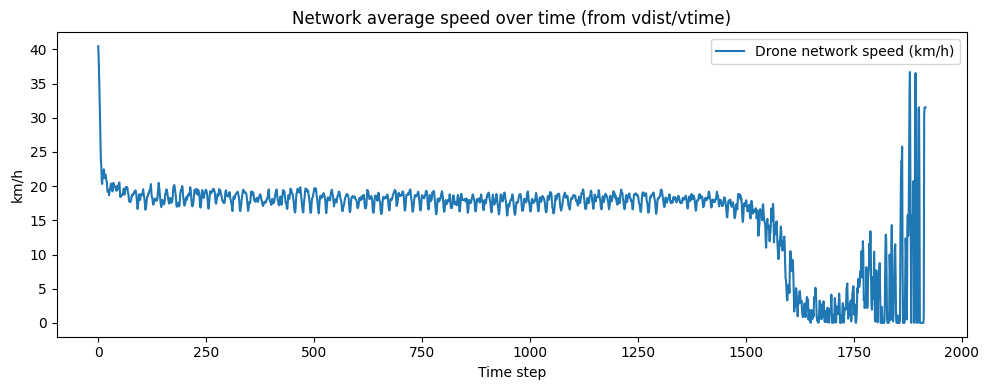

In [36]:
plt.figure(figsize=(10, 4))
plt.plot(drone_speed_kmh_t.values, label="Drone network speed (km/h)")
plt.title("Network average speed over time (from vdist/vtime)")
plt.xlabel("Time step")
plt.ylabel("km/h")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Option A: by degree
deg_series = pd.Series(dict(G.degree()))
picked_nodes = deg_series.sort_values(ascending=False).head(6).index.tolist()

# Option B: manually 
# picked_nodes = [18704, 18708, 18723, 593, 600, 595]  # example only

picked_nodes

[9808, 9576, 13226, 8276, 9831, 9830]

In [38]:
def safe_div(a, b):
    return a / b.replace(0, np.nan)

# Drone per-link speed (m/s) -> km/h
drone_speed_link_kmh = safe_div(drone_vdist, drone_vtime) * 3.6

# Pred per-link speed (m/s) -> km/h
pred_speed_link_kmh = safe_div(pred_vdist, pred_vtime) * 3.6

# ld_speed: unknown units; assume m/s -> km/h if values look like 0-40
ld_speed_vals = pd.to_numeric(ld_speed.stack(), errors="coerce").dropna().to_numpy()
ld_p95 = np.percentile(ld_speed_vals, 95) if ld_speed_vals.size else np.nan
ld_speed_link_kmh = ld_speed * (3.6 if (np.isfinite(ld_p95) and ld_p95 <= 40) else 1.0)

print("LD p95:", ld_p95, "-> converted to km/h?" , (np.isfinite(ld_p95) and ld_p95 <= 40))

LD p95: 11.680409883121246 -> converted to km/h? True


In [39]:
# If drone_vdist index is NOT datetime, create a synthetic datetime index
# Use a dt_sec you inferred earlier (defaulting to 5s is typical for drone, but your file is 'all_agg')
# You can adjust dt_sec if you know the exact aggregation interval.
dt_sec = 5.0  # change if needed
if not isinstance(drone_speed_link_kmh.index, pd.DatetimeIndex):
    start = pd.Timestamp("2024-01-01 00:00:00")  # arbitrary anchor
    drone_speed_link_kmh.index = start + pd.to_timedelta(np.arange(len(drone_speed_link_kmh)) * dt_sec, unit="s")

# For pred/ld, do same if they aren't datetime
if not isinstance(pred_speed_link_kmh.index, pd.DatetimeIndex):
    start = drone_speed_link_kmh.index[0]
    pred_speed_link_kmh.index = start + pd.to_timedelta(np.arange(len(pred_speed_link_kmh)) * dt_sec, unit="s")

if not isinstance(ld_speed_link_kmh.index, pd.DatetimeIndex):
    start = drone_speed_link_kmh.index[0]
    ld_speed_link_kmh.index = start + pd.to_timedelta(np.arange(len(ld_speed_link_kmh)) * dt_sec, unit="s")

drone_speed_link_kmh.index[:3], pred_speed_link_kmh.index[:3]

(DatetimeIndex(['2005-05-10 07:45:05', '2005-05-10 07:45:10',
                '2005-05-10 07:45:15'],
               dtype='datetime64[ms]', name='time', freq=None),
 DatetimeIndex(['2005-05-10 07:48:00', '2005-05-10 07:51:00',
                '2005-05-10 07:54:00'],
               dtype='datetime64[ms]', name='time', freq=None))

In [40]:
nodes = picked_nodes

drone_panel = drone_speed_link_kmh[nodes].copy()
pred_panel  = pred_speed_link_kmh[nodes].copy()
ld_panel    = ld_speed_link_kmh[nodes].copy()

drone_panel.head()

,9808,9576,13226,8276,9831,9830
time,,,,,,
2005-05-10 07:45:05,NaN,NaN,NaN,NaN,NaN,NaN
2005-05-10 07:45:10,NaN,NaN,NaN,NaN,NaN,NaN
2005-05-10 07:45:15,NaN,NaN,NaN,45.300352,NaN,NaN
2005-05-10 07:45:20,NaN,NaN,NaN,26.959722,NaN,NaN
2005-05-10 07:45:25,NaN,NaN,NaN,12.257497,NaN,NaN


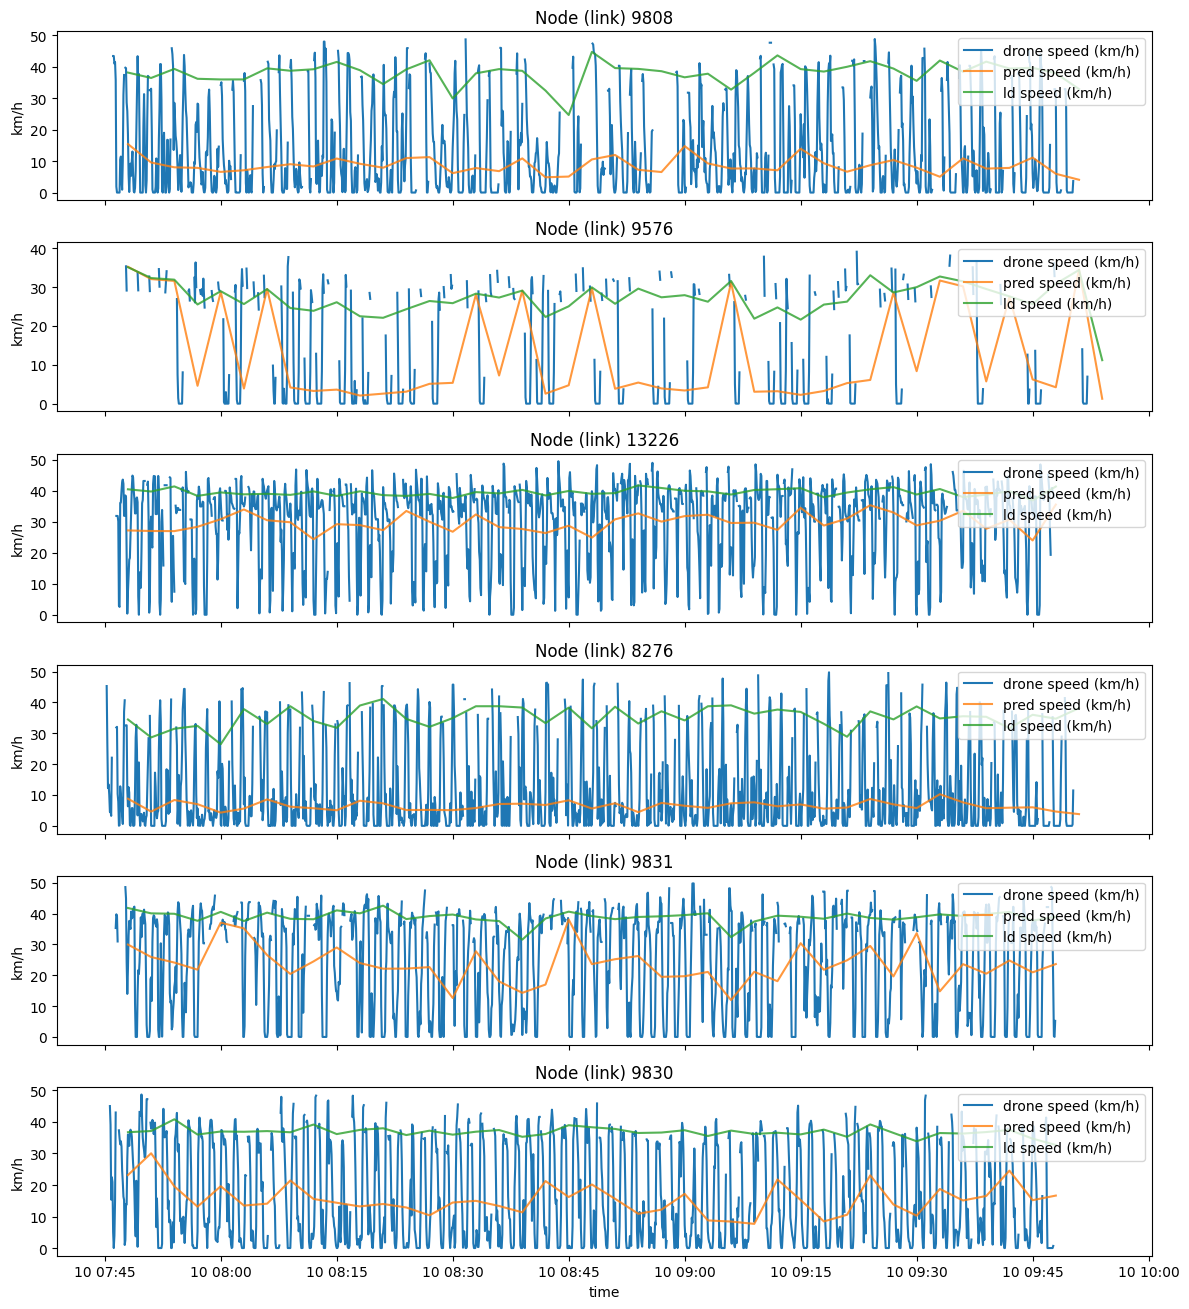

In [41]:
fig, axes = plt.subplots(len(nodes), 1, figsize=(12, 2.2*len(nodes)), sharex=True)

for i, nid in enumerate(nodes):
    ax = axes[i]
    ax.plot(drone_panel.index, drone_panel[nid], label="drone speed (km/h)")
    
    # overlay pred/ld if you want
    if nid in pred_panel.columns:
        ax.plot(pred_panel.index, pred_panel[nid], label="pred speed (km/h)", alpha=0.8)
    if nid in ld_panel.columns:
        ax.plot(ld_panel.index, ld_panel[nid], label="ld speed (km/h)", alpha=0.8)

    ax.set_title(f"Node (link) {nid}")
    ax.set_ylabel("km/h")
    ax.legend(loc="upper right")

plt.xlabel("time")
plt.tight_layout()
plt.show()

In [43]:
# Hourly mean speed per node (drone)
drone_hourly = drone_panel.resample("1h").mean()

# Hourly mean speed per node (pred/ld) if you want
pred_hourly = pred_panel.resample("1h").mean()
ld_hourly   = ld_panel.resample("1h").mean()

drone_hourly.head()

,9808,9576,13226,8276,9831,9830
time,,,,,,
2005-05-10 07:00:00,13.882083,24.622341,28.565208,11.508323,25.880988,21.342357
2005-05-10 08:00:00,12.752156,11.689034,29.430159,11.210110,24.339361,16.753503
2005-05-10 09:00:00,13.074864,12.107526,30.162306,10.476568,23.179730,15.334660
2005-05-10 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN


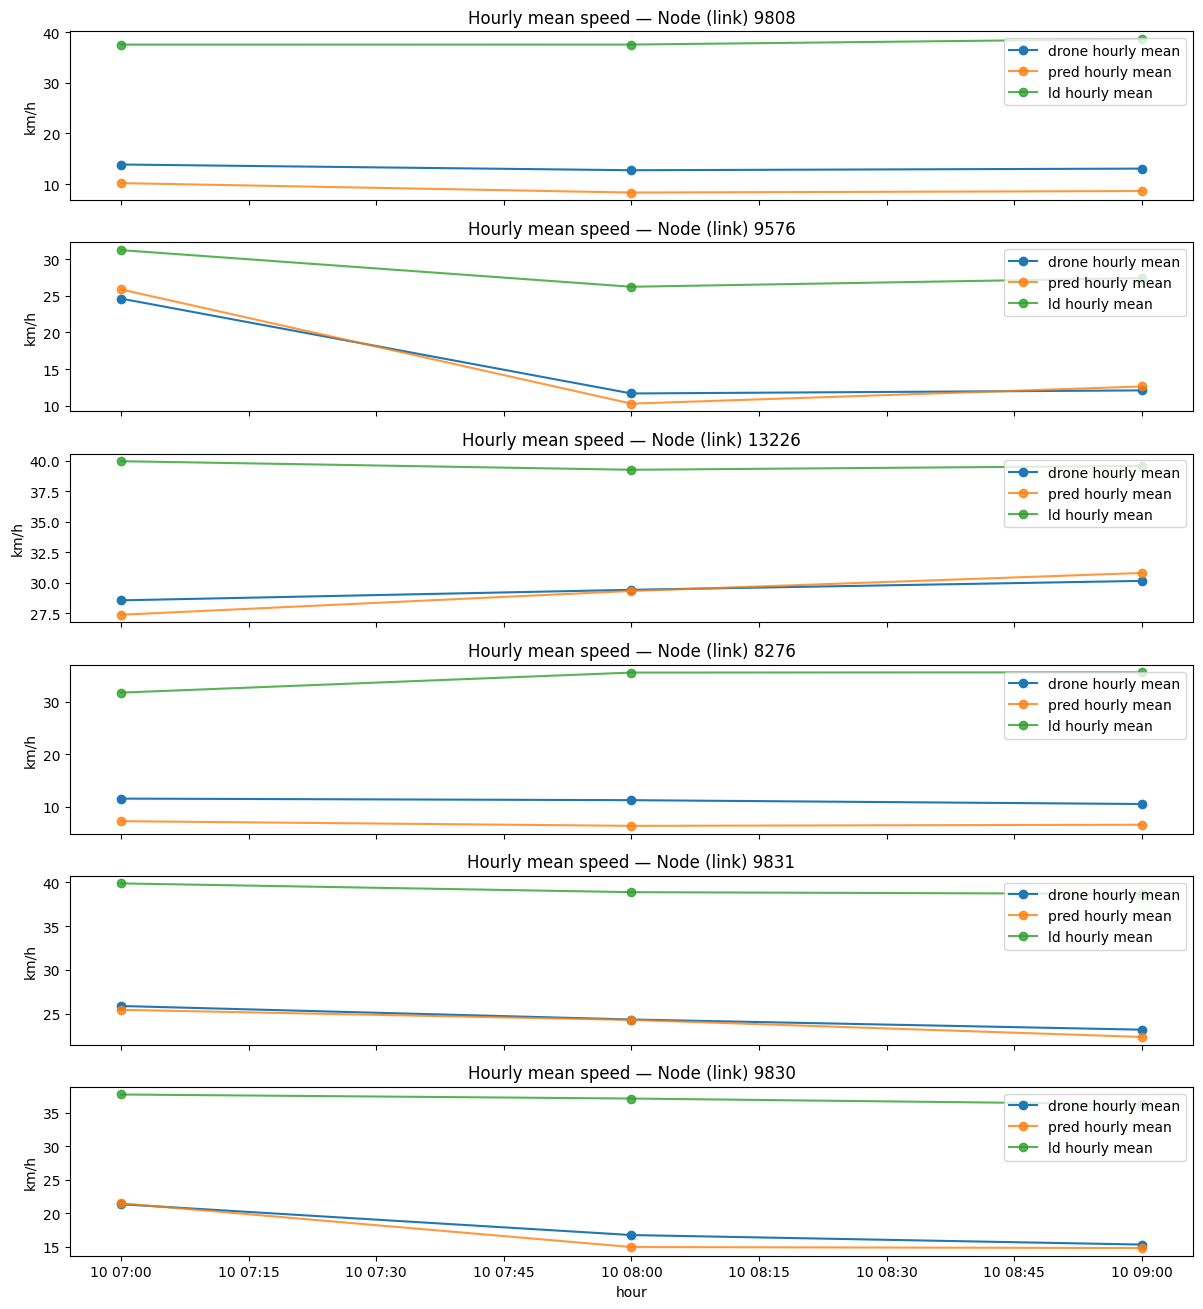

In [44]:
fig, axes = plt.subplots(len(nodes), 1, figsize=(12, 2.2*len(nodes)), sharex=True)

for i, nid in enumerate(nodes):
    ax = axes[i]
    ax.plot(drone_hourly.index, drone_hourly[nid], marker="o", label="drone hourly mean")
    
    # optional overlays
    if nid in pred_hourly.columns:
        ax.plot(pred_hourly.index, pred_hourly[nid], marker="o", label="pred hourly mean", alpha=0.8)
    if nid in ld_hourly.columns:
        ax.plot(ld_hourly.index, ld_hourly[nid], marker="o", label="ld hourly mean", alpha=0.8)

    ax.set_title(f"Hourly mean speed — Node (link) {nid}")
    ax.set_ylabel("km/h")
    ax.legend(loc="upper right")

plt.xlabel("hour")
plt.tight_layout()
plt.show()

In [ ]:
nid = nodes[0]  
print("drone_vtime zeros:", (drone_vtime[nid] == 0).sum())
print("drone_vtime NaNs :", drone_vtime[nid].isna().sum())

drone_vtime zeros: 0
drone_vtime NaNs : 677
